In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,roc_curve,
    precision_recall_curve,average_precision_score
)
# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


In [2]:
df = pd.read_csv('Adult Census Income.csv')

In [3]:
df .head(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

In [7]:
df.shape 


(32561, 15)

In [8]:
df.describe(include="object")

,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [9]:
df = df.replace('?', np.nan)

In [10]:
df.isna().sum().sort_values(ascending=False)


occupation        1843
workclass         1836
native.country     583
fnlwgt               0
education            0
education.num        0
age                  0
marital.status       0
relationship         0
sex                  0
race                 0
capital.gain         0
capital.loss         0
hours.per.week       0
income               0
dtype: int64

In [11]:
y = df['income']
x= df.drop('income', axis=1)

In [12]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')
cols= ["occupation", "workclass", "native.country"]
df[cols] = imputer.fit_transform(df[cols])

In [13]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

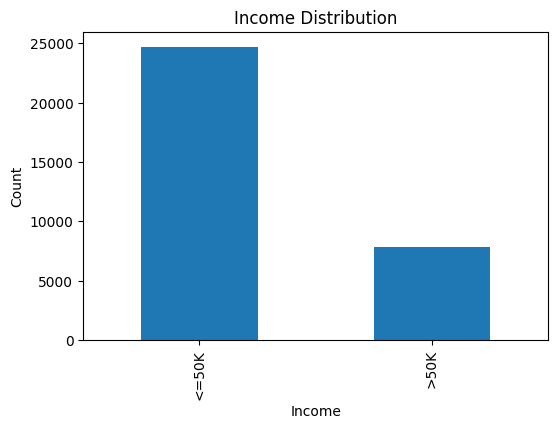

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["income"].value_counts().plot(kind="bar")

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

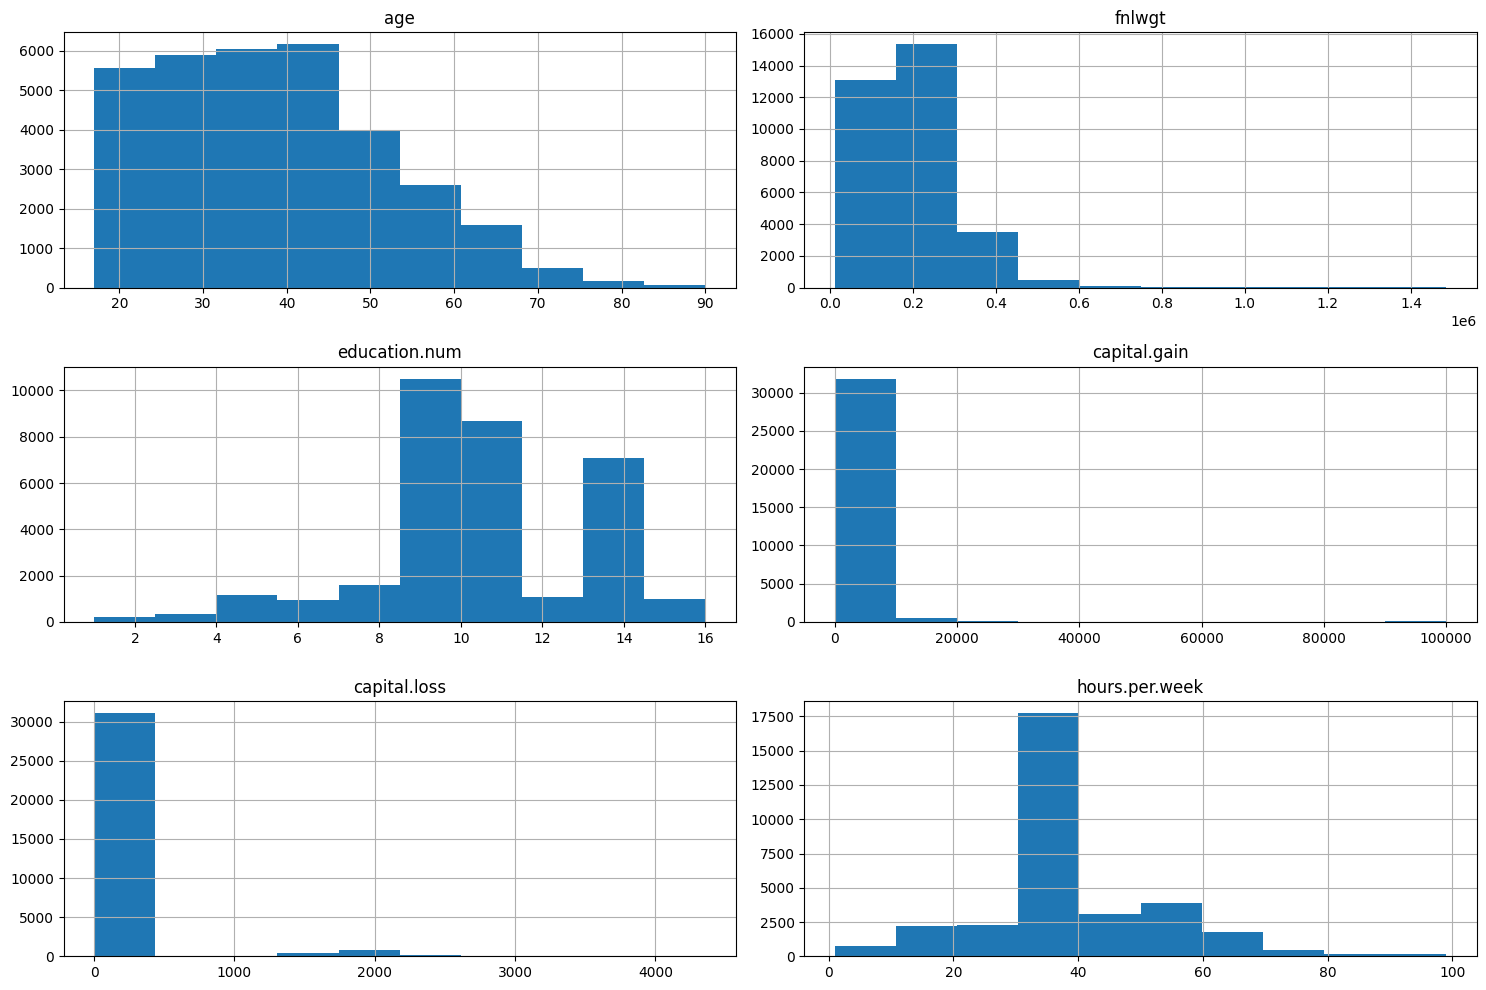

In [15]:
num_cols = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

df[num_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

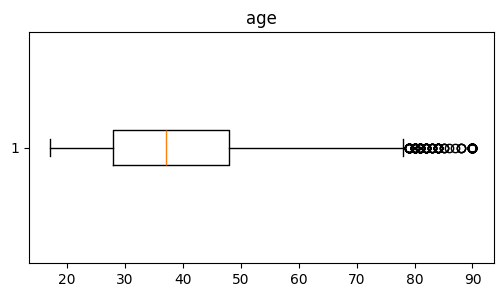

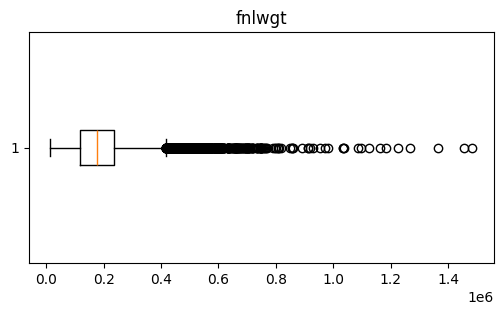

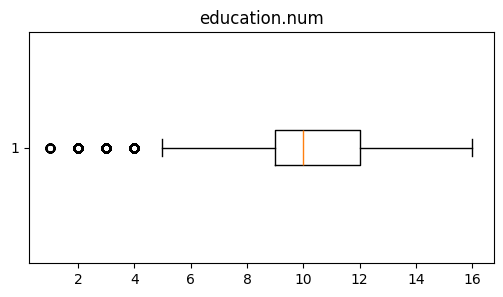

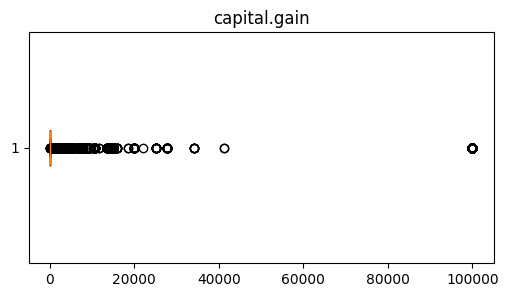

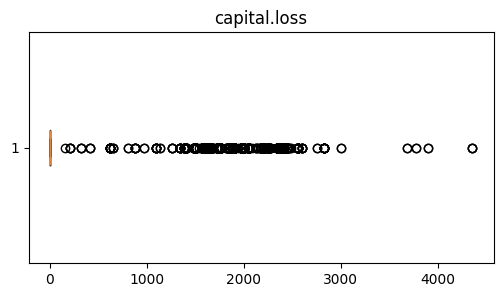

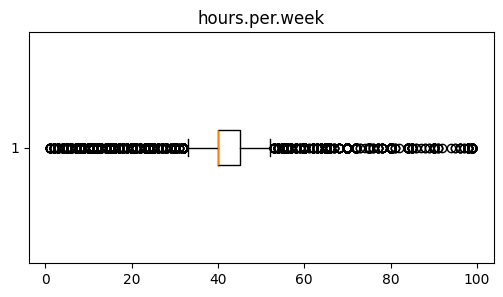

In [16]:
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

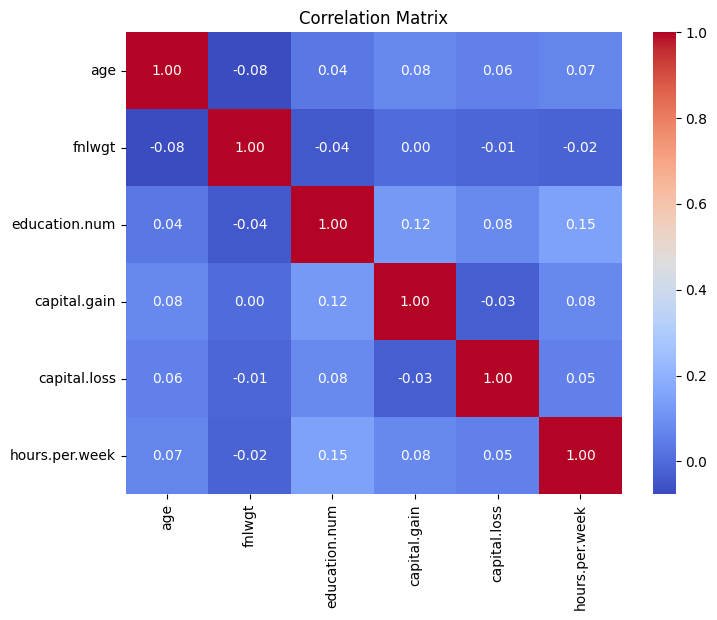

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()


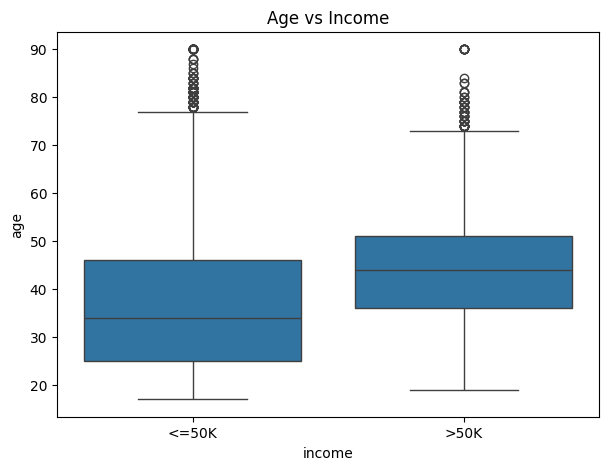

In [18]:
plt.figure(figsize=(7,5))

sns.boxplot(x="income", y="age", data=df)

plt.title("Age vs Income")
plt.show()

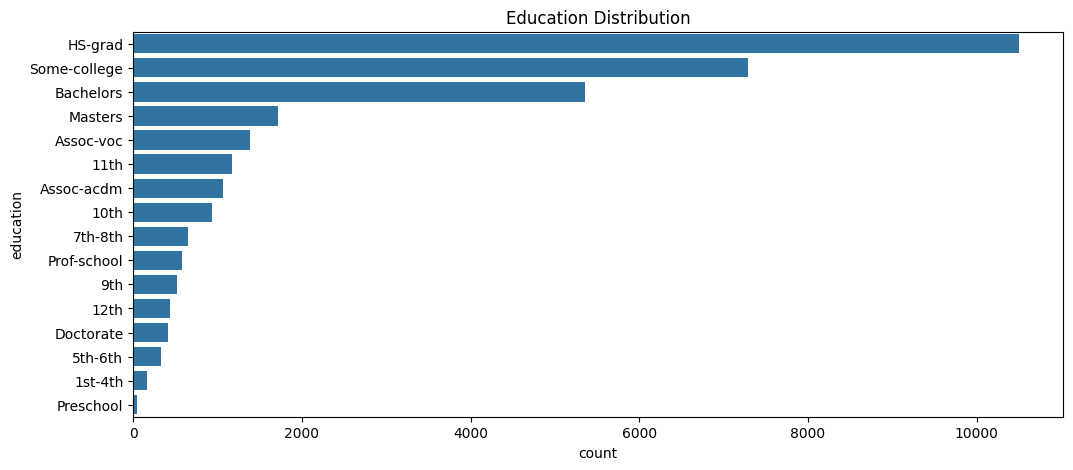

In [19]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    y="education",
    order=df["education"].value_counts().index
)

plt.title("Education Distribution")
plt.show()

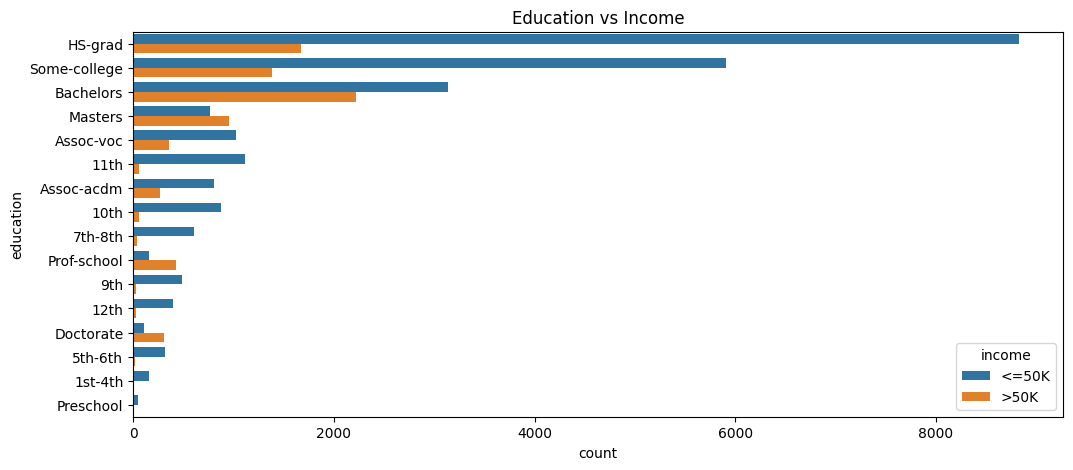

In [20]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    y="education",
    hue="income",
    order=df["education"].value_counts().index
)

plt.title("Education vs Income")
plt.show()

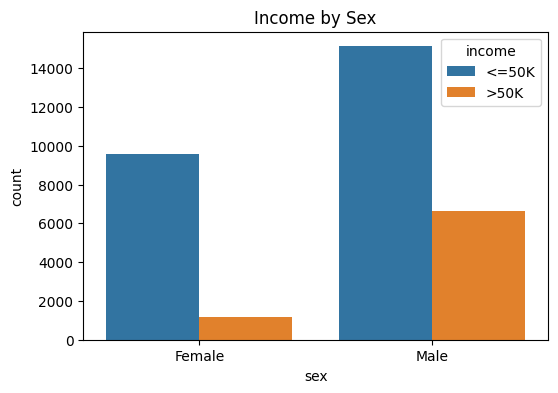

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="sex",
    hue="income"
)

plt.title("Income by Sex")
plt.show()

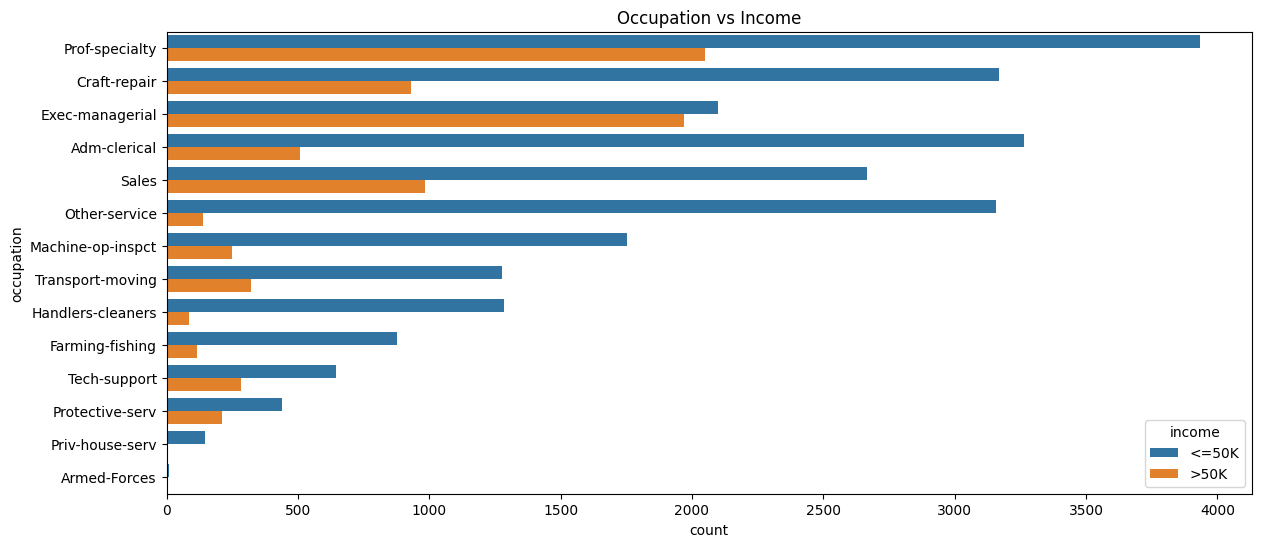

In [22]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    y="occupation",
    hue="income",
    order=df["occupation"].value_counts().index
)

plt.title("Occupation vs Income")
plt.show()

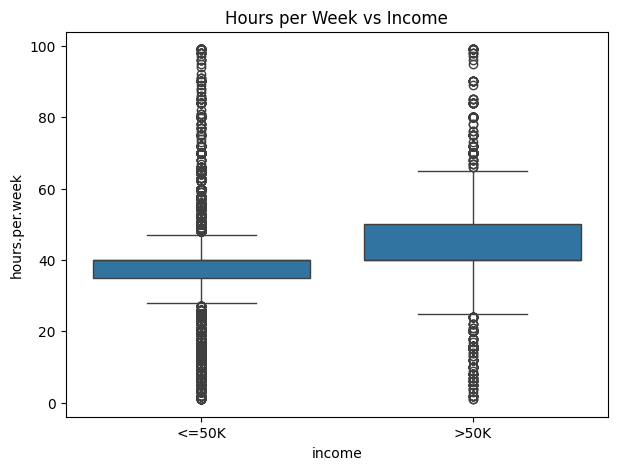

In [23]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="income",
    y="hours.per.week"
)

plt.title("Hours per Week vs Income")
plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

In [25]:
cat_cols = x_train.select_dtypes(include="object").columns
print(cat_cols)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country'],
      dtype='object')


In [26]:
num_cols = x_train.select_dtypes(exclude="object").columns
print(num_cols)

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')


In [27]:


cat_cols = x_train.select_dtypes(include="object").columns

for col in cat_cols:
    le = LabelEncoder()
    x_train[col] = le.fit_transform(x_train[col])
    x_test[col] = le.transform(x_test[col])

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pred = model.predict(x_test)

acc = accuracy_score(y_test, pred)
cm = confusion_matrix(y_test, pred)
report = classification_report(y_test, pred)

print("=" * 50)
print(f"          {model.__class__.__name__} Results")
print("=" * 50)

print(f"\nAccuracy : {acc:.4f}")

print("\nClassification Report")
print("-" * 50)
print(report)

print("Confusion Matrix")
print("-" * 50)
print(cm)

print("=" * 50)

          LogisticRegression Results

Accuracy : 0.8244

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      4976
           1       0.70      0.45      0.54      1537

    accuracy                           0.82      6513
   macro avg       0.77      0.69      0.72      6513
weighted avg       0.81      0.82      0.81      6513

Confusion Matrix
--------------------------------------------------
[[4684  292]
 [ 852  685]]


In [31]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)
pred = model.predict(x_test)

In [35]:
models = {

    # Linear
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1),

    # Distance-based
    "KNN": KNeighborsClassifier(n_neighbors=5),

    # SVM
    "SVC": SVC(probability=True, random_state=1),

    # Tree
    "Decision Tree": DecisionTreeClassifier(random_state=1),

    # Naive Bayes
    "Naive Bayes": GaussianNB(),

    # Bagging Based
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=1),

    # Boosting
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1),

    # External Boosting Libraries
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=1, use_label_encoder=False),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=1),
    "LightGBM": LGBMClassifier(random_state=1)
}

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for model_name, model in models.items():

    model.fit(x_train, y_train)

    pred = model.predict(x_test)

    results.append([
        model_name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

c:\Users\Naseer\anaconda3\envs\tf_env\lib\site-packages\xgboost\training.py:200: UserWarning: [10:41:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 6304, number of negative: 19744
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000798 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 694
[LightGBM] [Info] Number of data points in the train set: 26048, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.242015 -> initscore=-1.141665
[LightGBM] [Info] Start training from score -1.141665


In [38]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df.round(4))

                     Model  Accuracy  Precision  Recall  F1-Score
12                LightGBM    0.8756     0.7924  0.6409    0.7086
9   Hist Gradient Boosting    0.8735     0.7814  0.6441    0.7061
11                CatBoost    0.8713     0.7794  0.6344    0.6994
10                 XGBoost    0.8701     0.7664  0.6467    0.7015
8        Gradient Boosting    0.8649     0.7973  0.5732    0.6669
5            Random Forest    0.8532     0.7257  0.6077    0.6615
7                 AdaBoost    0.8480     0.7684  0.5094    0.6127
6              Extra Trees    0.8439     0.6940  0.6051    0.6465
0      Logistic Regression    0.8244     0.7011  0.4457    0.5449
1                      KNN    0.8222     0.6415  0.5589    0.5974
3            Decision Tree    0.8107     0.5982  0.6025    0.6003
2                      SVC    0.8104     0.8120  0.2557    0.3889
4              Naive Bayes    0.8025     0.6662  0.3273    0.4389


In [39]:
results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1-Score
12,LightGBM,0.8756,0.7924,0.6409,0.7086
9,Hist Gradient Boosting,0.8735,0.7814,0.6441,0.7061
11,CatBoost,0.8713,0.7794,0.6344,0.6994
10,XGBoost,0.8701,0.7664,0.6467,0.7015
8,Gradient Boosting,0.8649,0.7973,0.5732,0.6669
5,Random Forest,0.8532,0.7257,0.6077,0.6615
7,AdaBoost,0.8480,0.7684,0.5094,0.6127
6,Extra Trees,0.8439,0.6940,0.6051,0.6465
0,Logistic Regression,0.8244,0.7011,0.4457,0.5449
1,KNN,0.8222,0.6415,0.5589,0.5974
